# Pip this row

In [ ]:
pip install pyvi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 61.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import torch
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    TrainerCallback,
    EarlyStoppingCallback
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from pyvi import ViTokenizer
import re
import numpy as np
import os
from collections import Counter
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

# Import Data & Process Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Project_ChatBot/data/datafinal-promptv1.csv')

In [ ]:
print("Phân bố nhãn:")
print(df['severity'].value_counts())

Phân bố nhãn:
severity
Moderately Severe    1080
Severe               1079
Moderate             1079
Mild                 1014
Minimal              1007
Name: count, dtype: int64


In [ ]:
def plot_label_distribution(df):
    plt.figure(figsize=(10, 6))
    sns.countplot(x='severity', data=df, order=['Minimal', 'Mild', 'Moderate', 'Moderately Severe', 'Severe'])
    plt.title('Phân bố nhãn trong tập dữ liệu')
    plt.xlabel('Mức độ nghiêm trọng')
    plt.ylabel('Số lượng')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

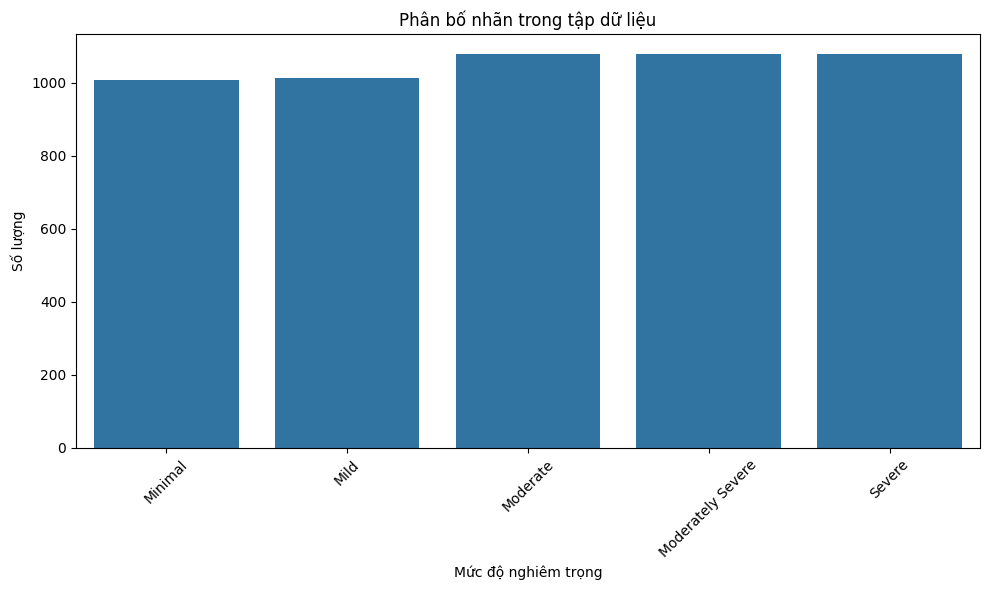

In [ ]:
plot_label_distribution(df)

In [ ]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'[^\w\s.,!?áàảãạăắằẳẵặâấầẩẫậéèẻẽẹêếềểễệíìỉĩịóòỏõọôốồổỗộơớờởỡợúùủũụưứừửữựýỳỷỹỵ]', ' ', text)
    text = re.sub(r'\b(\w+)\s+\1\b', r'\1', text)
    text = re.sub(r'(tôi\s+cảm\s+thấy\s+rằng,\s+)+', 'tôi cảm thấy rằng, ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    if len(words) > 120:
        text = ' '.join(words[:120])
    return text

In [ ]:
def preprocess_vietnamese_text(text):
    """Tách từ tiếng Việt bằng pyvi."""
    return ViTokenizer.tokenize(text)

In [ ]:
def validate_labels(df):
    """Kiểm tra và sửa nhãn Severity Level dựa trên PHQ-9 Score."""
    score_ranges = {
        (0, 4): 'Minimal',
        (5, 9): 'Mild',
        (10, 14): 'Moderate',
        (15, 19): 'Moderately Severe',
        (20, 27): 'Severe'
    }

    def get_severity(score):
        for (low, high), label in score_ranges.items():
            if low <= score <= high:
                return label
        return 'Minimal'

    df['Validated_Severity'] = df['phq9_score'].apply(get_severity)
    mismatches = df[df['severity'] != df['Validated_Severity']]
    if not mismatches.empty:
        print(f"Found {len(mismatches)} label mismatches. Correcting...")
        df.loc[:, 'severity'] = df['Validated_Severity']
    df = df.drop(columns=['Validated_Severity'])
    return df

In [ ]:
df['cleaned_text'] = df['text'].apply(clean_text)

In [ ]:
df['tokenized_text'] = df['cleaned_text'].apply(preprocess_vietnamese_text)

In [ ]:
df = validate_labels(df)

In [ ]:
#Features
df = df.drop_duplicates(subset=['tokenized_text'])

texts = df['tokenized_text'].values
labels = df['severity'].values

In [ ]:
valid_severities = ["Minimal", "Mild", "Moderate", "Moderately Severe", "Severe"]
df["phq9_score"] = pd.to_numeric(df["phq9_score"], errors="coerce")
df = df.dropna(subset=["phq9_score", "severity"])
df = df[df["phq9_score"].between(0, 27) & df["severity"].isin(valid_severities)]


# Summary
print("\n=== Summary ===")
print(f"Bộ dữ liệu chứa {len(df)} dữ liệu sinh viên với điểm PHQ-9 (0–27) và các loại mức độ nghiêm trọng: {', '.join(valid_severities)}. Các triệu chứng phổ biến bao gồm mệt mỏi, vấn đề về giấc ngủ và cảm giác tuyệt vọng.")
severity_counts = df["severity"].value_counts().reindex(valid_severities, fill_value=0)
bins = [0, 4, 9, 14, 19, 27]
bin_labels = ["0-4", "5-9", "10-14", "15-19", "20-27"]
df["score_range"] = pd.cut(df["phq9_score"], bins=bins, labels=bin_labels, include_lowest=True)
score_counts = df["score_range"].value_counts().reindex(bin_labels, fill_value=0)

# Symptom frequency analysis
symptoms = ["mệt mỏi", "mất ngủ", "chán đời", "mất tập trung", "thất bại"]
symptom_counts = {symptom: df["text"].str.contains(symptom, case=False, na=False).sum() for symptom in symptoms}
symptom_df = pd.DataFrame({"Symptom": symptoms, "Count": [symptom_counts[s] for s in symptoms]})


=== Summary ===
Bộ dữ liệu chứa 5111 dữ liệu sinh viên với điểm PHQ-9 (0–27) và các loại mức độ nghiêm trọng: Minimal, Mild, Moderate, Moderately Severe, Severe. Các triệu chứng phổ biến bao gồm mệt mỏi, vấn đề về giấc ngủ và cảm giác tuyệt vọng.


In [ ]:
# Visualizations
plt.style.use("seaborn-v0_8")
sns.set_palette("colorblind")

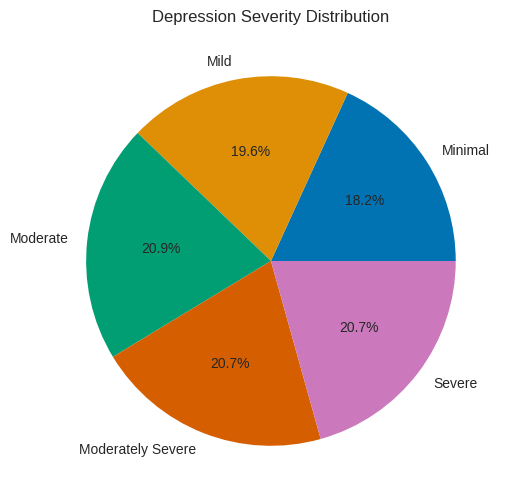

In [ ]:
# Pie Chart
plt.figure(figsize=(8, 6))
plt.pie(severity_counts, labels=severity_counts.index, autopct="%1.1f%%", colors=sns.color_palette("colorblind", len(severity_counts)))
plt.title("Depression Severity Distribution")
plt.show()

<ipython-input-18-6fbe02aa15e7>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bin_labels, y=score_counts, palette="colorblind")


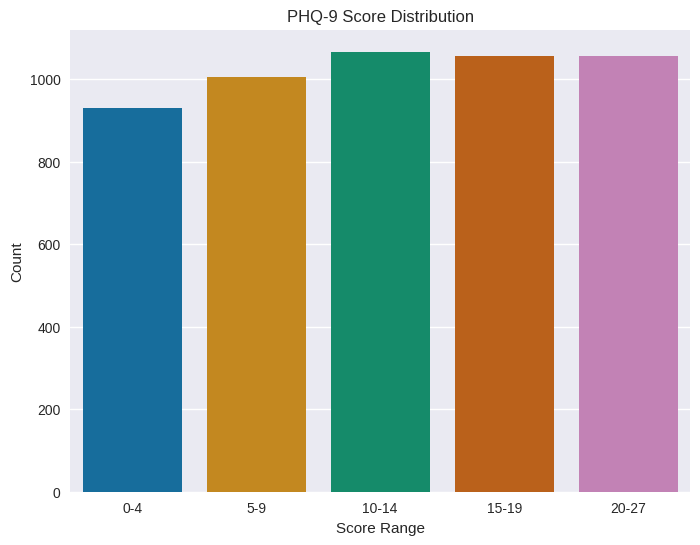

In [ ]:
# Bar Chart
plt.figure(figsize=(8, 6))
sns.barplot(x=bin_labels, y=score_counts, palette="colorblind")
plt.title("PHQ-9 Score Distribution")
plt.xlabel("Score Range")
plt.ylabel("Count")
plt.show()

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7879 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND DOT BELOW}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7887 (\N{LATIN SMALL LETTER O WITH HOOK ABOVE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7845 (\N{LATIN SMALL LETTER A WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7911 (\N{LATIN SMALL LETTER U WITH HOOK ABOVE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7901 (\N{

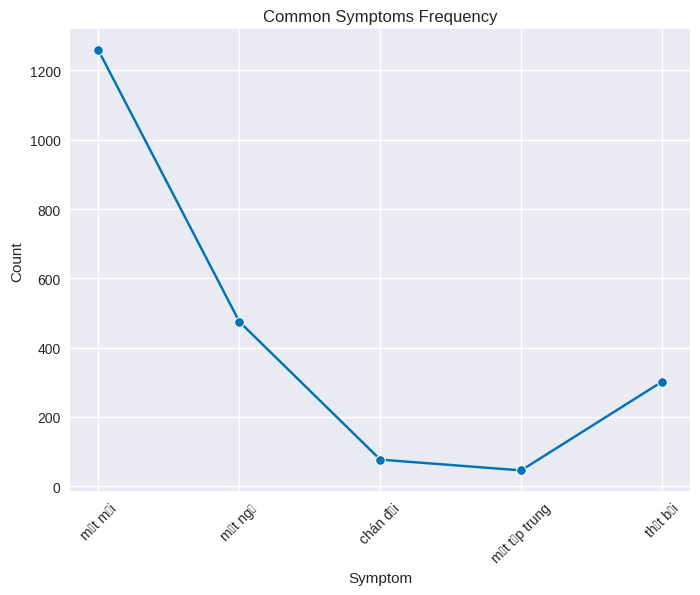

In [ ]:
plt.figure(figsize=(8, 6))
sns.lineplot(x="Symptom", y="Count", data=symptom_df, marker="o", color=sns.color_palette("colorblind")[0])
plt.title("Common Symptoms Frequency")
plt.xlabel("Symptom")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Build Classification Model- PhoBERT

In [ ]:
class PHQ9Dataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.label_map = {'Minimal': 0, 'Mild': 1, 'Moderate': 2, 'Moderately Severe': 3, 'Severe': 4}

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.label_map[self.labels[idx]]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [ ]:
from sklearn.metrics import f1_score, precision_recall_fscore_support
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    return {
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [ ]:
class ClassificationReportCallback(TrainerCallback):
    def __init__(self, trainer, test_dataset, label_map):
        self.trainer = trainer
        self.test_dataset = test_dataset
        self.label_map = label_map

    def on_epoch_end(self, args, state, control, **kwargs):
        predictions = self.trainer.predict(self.test_dataset)
        preds = np.argmax(predictions.predictions, axis=1)
        true_labels = predictions.label_ids
        preds = [self.label_map[p] for p in preds]
        true_labels = [self.label_map[l] for l in true_labels]
        print(f"\nClassification Report at Epoch {state.epoch}:")
        print(classification_report(true_labels, preds))
        print("\nConfusion Matrix:")
        print(confusion_matrix(true_labels, preds))

In [ ]:
class BestEpochNoOverfittingCallback(TrainerCallback):
    def __init__(self, trainer, eval_dataset, metric_name="f1", threshold=0.1):
        super().__init__()
        self.trainer = trainer
        self.eval_dataset = eval_dataset
        self.metric_name = metric_name
        self.threshold = threshold
        self.train_metrics = []
        self.eval_metrics = []
        self.best_eval_metric = -float("inf")
        self.best_epoch = 0
        self.best_train_metric = 0.0

    def on_epoch_end(self, args, state, control, **kwargs):
        train_results = self.trainer.evaluate(eval_dataset=self.trainer.train_dataset)
        train_metric = train_results[f"eval_{self.metric_name}"]
        self.train_metrics.append(train_metric)

        eval_results = self.trainer.evaluate(eval_dataset=self.eval_dataset)
        eval_metric = eval_results[f"eval_{self.metric_name}"]
        self.eval_metrics.append(eval_metric)

        # Kiểm tra overfitting
        metric_diff = abs(train_metric - eval_metric)
        print(f"Epoch {state.epoch}:")
        print(f"Train {self.metric_name}: {train_metric:.4f}")
        print(f"Eval {self.metric_name}: {eval_metric:.4f}")
        print(f"Difference ({self.metric_name}): {metric_diff:.4f}")

        # Cập nhật epoch tốt nhất nếu không có dấu hiệu overfitting
        if metric_diff <= self.threshold and eval_metric > self.best_eval_metric:
            self.best_eval_metric = eval_metric
            self.best_train_metric = train_metric
            self.best_epoch = state.epoch
            print(f"New best epoch: {self.best_epoch} with Eval {self.metric_name}: {self.best_eval_metric:.4f}")

        if metric_diff > self.threshold:
            print(f"Cảnh báo: Đã phát hiện Overfitting! Sự khác biệt trong {self.metric_name} ({metric_diff:.4f}) vượt quá ngưỡng ({self.threshold}).")

    def on_train_end(self, args, state, control, **kwargs):
        print(f"Training completed. Best epoch: {self.best_epoch} with Eval {self.metric_name}: {self.best_eval_metric:.4f}")

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")
model = AutoModelForSequenceClassification.from_pretrained(
    "vinai/phobert-base", num_labels=5,ignore_mismatched_sizes=True).to(device)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/895k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.13M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/phobert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
label_mapping = {
    0: "Minimal",
    1: "Mild",
    2: "Moderate",
    3: "Moderately Severe",
    4: "Severe"
}

In [ ]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
        texts, labels, test_size=0.2, random_state=42, stratify=labels
    )

max_len = 256
train_dataset = PHQ9Dataset(train_texts, train_labels, tokenizer, max_len)
val_dataset = PHQ9Dataset(val_texts, val_labels, tokenizer, max_len)

In [ ]:
print("Số lượng nhãn trong tập train:")
print(Counter(train_labels))

print("\nSố lượng nhãn trong tập val:")
print(Counter(val_labels))

Số lượng nhãn trong tập train:
Counter({'Moderate': 852, 'Severe': 845, 'Moderately Severe': 845, 'Mild': 803, 'Minimal': 743})

Số lượng nhãn trong tập val:
Counter({'Moderate': 214, 'Severe': 211, 'Moderately Severe': 211, 'Mild': 201, 'Minimal': 186})


In [ ]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=15,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    learning_rate=3e-5,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1",
    greater_is_better=True,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    gradient_accumulation_steps=1,
    lr_scheduler_type="cosine",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.add_callback(EarlyStoppingCallback(
    early_stopping_patience=3,
    early_stopping_threshold=0.01
))

trainer.add_callback(ClassificationReportCallback(trainer, val_dataset, label_mapping))

trainer.train()

<IPython.core.display.Javascript object>

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: tranthanhdat2301 (tranthanhdat2301-ton-duc-thang-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.927900,0.891412,0.665425,0.654936,0.650007
2,0.666500,0.567914,0.807258,0.764418,0.768403
3,0.491000,0.520195,0.834149,0.794721,0.799422
4,0.488500,0.491850,0.828384,0.809384,0.810713
5,0.239700,0.413032,0.858968,0.843597,0.845340
6,0.341700,0.467587,0.848320,0.844575,0.842936
7,0.119100,0.338478,0.894626,0.887586,0.887960
8,0.177700,0.398315,0.897220,0.887586,0.888245
9,0.130600,0.323537,0.924965,0.922776,0.923270
10,0.028900,0.364652,0.925337,0.921799,0.922462



Classification Report at Epoch 1.0:
                   precision    recall  f1-score   support

             Mild       0.72      0.72      0.72       201
          Minimal       0.88      0.85      0.86       186
         Moderate       0.61      0.60      0.61       214
Moderately Severe       0.63      0.38      0.48       211
           Severe       0.52      0.75      0.62       211

         accuracy                           0.65      1023
        macro avg       0.67      0.66      0.66      1023
     weighted avg       0.67      0.65      0.65      1023


Confusion Matrix:
[[144  22   3   0  32]
 [  3 158   4   2  19]
 [ 44   0 129   3  38]
 [  5   0  71  81  54]
 [  5   0   5  43 158]]

Classification Report at Epoch 2.0:
                   precision    recall  f1-score   support

             Mild       0.98      0.63      0.76       201
          Minimal       0.99      0.84      0.91       186
         Moderate       0.80      0.65      0.72       214
Moderately Severe   

TrainOutput(global_step=3584, training_loss=0.321583648025158, metrics={'train_runtime': 1905.2404, 'train_samples_per_second': 32.185, 'train_steps_per_second': 2.015, 'total_flos': 7529388764749824.0, 'train_loss': 0.321583648025158, 'epoch': 14.0})

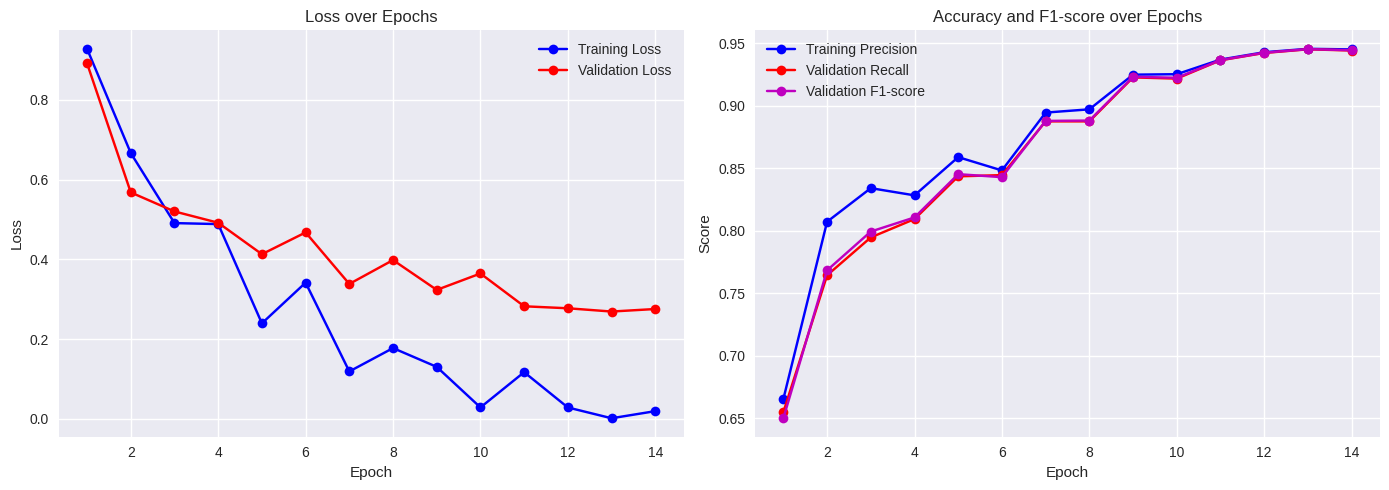

In [ ]:
epochs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

training_loss = [0.927900, 0.666500, 0.491000, 0.488500, 0.239700, 0.341700, 0.119100,
                 0.177700, 0.130600, 0.028900, 0.117300, 0.028800, 0.001800, 0.019600]

validation_loss = [0.891412, 0.567914, 0.520195, 0.491850, 0.413032, 0.467587, 0.338478,
                   0.398315, 0.323537, 0.364652, 0.282449, 0.277498, 0.269290, 0.275635]

precision = [0.665425, 0.807258, 0.834149, 0.828384, 0.858968, 0.848320, 0.894626,
             0.897220, 0.924965, 0.925337, 0.937034, 0.942919, 0.945658, 0.945182]

recall = [0.654936, 0.764418, 0.794721, 0.809384, 0.843597, 0.844575, 0.887586,
          0.887586, 0.922776, 0.921799, 0.936461, 0.942326, 0.945259, 0.944282]

f1 = [0.650007, 0.768403, 0.799422, 0.810713, 0.845340, 0.842936, 0.887960,
      0.888245, 0.923270, 0.922462, 0.936607, 0.942506, 0.945381, 0.944516]

# Plot Loss
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, training_loss, 'bo-', label='Training Loss')
plt.plot(epochs, validation_loss, 'ro-', label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy and F1
plt.subplot(1, 2, 2)
plt.plot(epochs, precision, 'bo-', label='Training Precision')
plt.plot(epochs, recall, 'ro-', label='Validation Recall')
plt.plot(epochs, f1, 'mo-', label='Validation F1-score')
plt.title('Accuracy and F1-score over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
for checkpoint in ['checkpoint-3328', 'checkpoint-3584']:
    model = AutoModelForSequenceClassification.from_pretrained(f'./results/{checkpoint}')
    trainer = Trainer(model=model, args=training_args, eval_dataset=val_dataset, compute_metrics=compute_metrics)
    results = trainer.evaluate()
    print(f"Results for {checkpoint}:", results)

Results for checkpoint-3328: {'eval_loss': 0.26929008960723877, 'eval_model_preparation_time': 0.0051, 'eval_precision': 0.9456581021782162, 'eval_recall': 0.9452590420332356, 'eval_f1': 0.9453813467176265, 'eval_runtime': 4.2204, 'eval_samples_per_second': 242.396, 'eval_steps_per_second': 15.165}


Results for checkpoint-3584: {'eval_loss': 0.27563509345054626, 'eval_model_preparation_time': 0.0065, 'eval_precision': 0.945181839027195, 'eval_recall': 0.9442815249266863, 'eval_f1': 0.9445156741854562, 'eval_runtime': 3.7318, 'eval_samples_per_second': 274.129, 'eval_steps_per_second': 17.15}


In [ ]:
model.save_pretrained("/content/drive/MyDrive/Project_ChatBot/model/PhoBERT_o3")
tokenizer.save_pretrained("/content/drive/MyDrive/Project_ChatBot/model/PhoBERT_o3")

('/content/drive/MyDrive/Project_ChatBot/model/PhoBERT_o3/tokenizer_config.json',
 '/content/drive/MyDrive/Project_ChatBot/model/PhoBERT_o3/special_tokens_map.json',
 '/content/drive/MyDrive/Project_ChatBot/model/PhoBERT_o3/vocab.txt',
 '/content/drive/MyDrive/Project_ChatBot/model/PhoBERT_o3/bpe.codes',
 '/content/drive/MyDrive/Project_ChatBot/model/PhoBERT_o3/added_tokens.json')

In [ ]:
eval_results = trainer.evaluate()
print(eval_results)

{'eval_loss': 0.26929008960723877, 'eval_precision': 0.9456581021782162, 'eval_recall': 0.9452590420332356, 'eval_f1': 0.9453813467176265, 'eval_runtime': 4.2202, 'eval_samples_per_second': 242.404, 'eval_steps_per_second': 15.165, 'epoch': 14.0}


In [ ]:
df_test = pd.read_csv('/content/drive/MyDrive/Project_ChatBot/data/test_data_validated.csv')

In [ ]:
texts = df_test['text'].tolist()
labels = df_test['severity'].tolist()

In [ ]:
test_dataset = PHQ9Dataset(texts, labels, tokenizer, max_len=256)

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained('/content/drive/MyDrive/Project_ChatBot/model/PhoBERT_o3/')

training_args = TrainingArguments(
    output_dir='./results',
    per_device_eval_batch_size=16,
    fp16=torch.cuda.is_available(),
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [ ]:
# 3. Đánh giá trên tập test
test_results = trainer.evaluate()
print("Test Results:", test_results)

Test Results: {'eval_loss': 3.571601152420044, 'eval_model_preparation_time': 0.0428, 'eval_precision': 0.46907901146004916, 'eval_recall': 0.44666666666666666, 'eval_f1': 0.4463790415571237, 'eval_runtime': 2.4717, 'eval_samples_per_second': 60.687, 'eval_steps_per_second': 4.046}


In [ ]:
predictions = trainer.predict(test_dataset)
pred_labels = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

# In classification report
label_names = ['Minimal', 'Mild', 'Moderate', 'Moderately Severe', 'Severe']
print("\nClassification Report:")
print(classification_report(true_labels, pred_labels, target_names=label_names))


Classification Report:
                   precision    recall  f1-score   support

          Minimal       0.56      0.31      0.40        29
             Mild       0.37      0.36      0.36        28
         Moderate       0.38      0.55      0.44        22
Moderately Severe       0.39      0.50      0.44        32
           Severe       0.59      0.51      0.55        39

         accuracy                           0.45       150
        macro avg       0.46      0.45      0.44       150
     weighted avg       0.47      0.45      0.45       150



In [ ]:
from transformers import AutoModel, AutoConfig
from safetensors.torch import load_file
import torch

config = AutoConfig.from_pretrained("/content/drive/MyDrive/Project_ChatBot/model/PhoBERT_o3", trust_remote_code=True)
state_dict = load_file("/content/drive/MyDrive/Project_ChatBot/model/PhoBERT_o3/model.safetensors")
model = AutoModelForSequenceClassification.from_config(config)
model.load_state_dict(state_dict)

torch.save(model.state_dict(), "pytorch_model.bin")


In [ ]:
def predict(text, model, tokenizer, max_len=256):
    model.eval()
    encoding = tokenizer(
        text,
        add_special_tokens=True,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        pred = torch.argmax(outputs.logits, dim=1).cpu().numpy()[0]

    label_map = {0: 'Minimal', 1: 'Mild', 2: 'Moderate', 3: 'Moderately Severe', 4: 'Severe'}
    return label_map[pred]

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = AutoModelForSequenceClassification.from_pretrained("/content/drive/MyDrive/Project_ChatBot/model/PhoBERT_o3")
model.to(device)
tokenizer = AutoTokenizer.from_pretrained("/content/drive/MyDrive/Project_ChatBot/model/PhoBERT_o3")

In [ ]:
sample_text = """
    Gần đây tôi thấy mình chẳng còn hứng thú làm gì nữa, kể cả những việc trước kia rất thích.
    Nhiều lúc tôi thấy lòng nặng trĩu, kiểu như chẳng còn gì khiến tôi thấy khá hơn.
Mấy hôm rồi tôi ngủ li bì đến tận trưa, dù đêm ngủ cũng chẳng ngon giấc.
Cứ mỗi sáng thức dậy là tôi thấy như bị rút hết năng lượng, chẳng muốn rời khỏi giường.
Tôi cảm thấy mình chẳng làm được gì ra hồn, lúc nào cũng thấy mình là gánh nặng.
Đọc một đoạn văn mà tôi cứ phải đọc đi đọc lại mới hiểu, đầu óc cứ trôi đâu mất.
Tôi hay đi qua đi lại không kiểm soát được, ngồi một chỗ mà lòng cứ bứt rứt.
Cũng có lúc tôi thấy mình biến mất thì mọi người sẽ đỡ khổ hơn.
    """
prediction = predict(sample_text, model, tokenizer)
print(f"Predicted Severity Level: {prediction}")

Predicted Severity Level: Severe


In [ ]:
from torch.utils.data import Dataset, DataLoader

In [ ]:
def evaluate_model(model, dataset, device):
    model.eval()
    predictions = []
    true_labels = []
    for batch in DataLoader(dataset, batch_size=16):
        inputs = {key: val.to(device) for key, val in batch.items() if key != "labels"}
        labels = batch["labels"].to(device)
        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs["logits"]
            preds = torch.argmax(logits, dim=1)
        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())
    accuracy = accuracy_score(true_labels, predictions)
    f1 = f1_score(true_labels, predictions, average='macro')
    return predictions, accuracy, f1

In [ ]:
base_model = AutoModelForSequenceClassification.from_pretrained(
    "vinai/phobert-base", num_labels=5
)
base_model.to(device)
base_preds, base_accuracy, base_f1 = evaluate_model(base_model, test_dataset, device)
print("\nBase Model (No Fine-tuning):")
print(f"Accuracy: {base_accuracy:.4f}")
print(f"F1 Scor: {base_f1:.4f}")

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/phobert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Base Model (No Fine-tuning):
Accuracy: 0.2200
F1 Scor: 0.1345
